A media company publishes thousands of news articles daily.
Problems they face:
Articles are not consistently tagged
Manual categorization is expensive
New topics emerge frequently
The company wants to:
Automatically group similar news articles
Discover hidden themes without defining categories upfront
Build a content recommendation system
They hire you as a Data Analyst to discover natural article groupings using data — without knowing how many topics exist.
 
1. 1️⃣ Data Understanding & Feature Selection
Load the dataset
Identify the column containing news text
Ignore any sentiment or category labels
Task:
Convert text into numerical form using TF-IDF
Limit features to a reasonable size (e.g., top 500–1000 words)
 
Dendrogram Construction & Analysis
Build a dendrogram using a subset of articles
Observe:
Where large vertical jumps occur
What they indicate about topic separation
 
Apply Hierarchical Clustering
Use Agglomerative Hierarchical Clustering
Choose an appropriate linkage method
 
Validation Without Labels (Critical Thinking)
Since this is unsupervised:
How do you judge clustering quality?
mertic:
Silhouette score 
 

In [1]:
import numpy as np
import pandas as pd

In [12]:
df = pd.read_csv(
    'Financial-data.csv',
    encoding='latin1',
    header=None,
    names=['sentiment','text']
)

In [13]:
df.head()

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4846 non-null   object
 1   text       4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [22]:
df.isnull().sum()

sentiment    0
text         0
dtype: int64

In [23]:
df["text"] = df["text"].astype(str).str.strip()

df = df[df["text"] != ""]
df = df.reset_index(drop=True)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2
)

X = vectorizer.fit_transform(df["text"])

print("TFIDF Shape:", X.shape)

TFIDF Shape: (4846, 3000)


In [25]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)

print(X_reduced.shape)


(4846, 50)


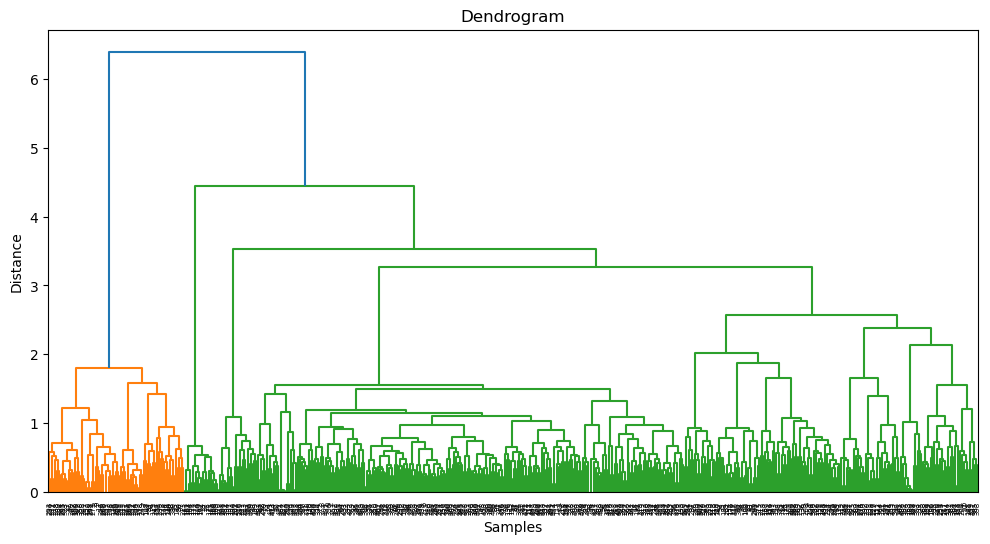

In [26]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(X_reduced[:500], method="ward")
)

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [27]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,          # adjust after dendrogram
    metric="cosine",
    linkage="average"
)

clusters = hc.fit_predict(X_reduced)

df["cluster"] = clusters


In [29]:
from sklearn.metrics import silhouette_score


score = silhouette_score(X_reduced, clusters, metric="cosine")
print("Silhouette Score:", score)

Silhouette Score: 0.08816996518295257


In [30]:
print(pd.crosstab(df["sentiment"], df["cluster"]))

cluster      0   1     2
sentiment               
negative   260   3   341
neutral    252  85  2542
positive   413   5   945


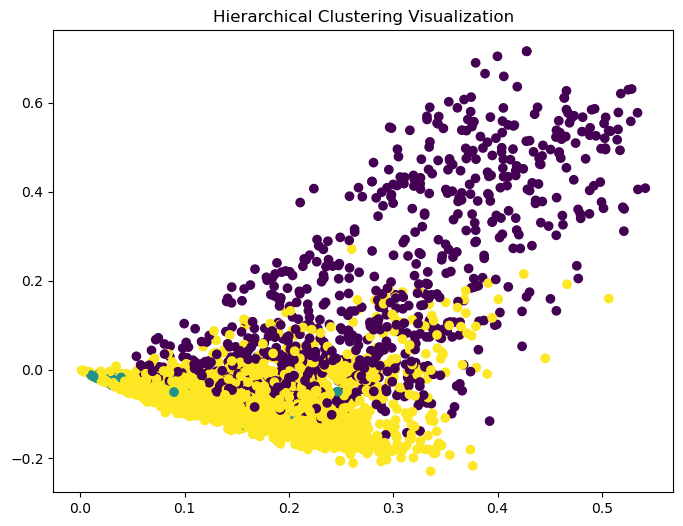

In [31]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters)
plt.title("Hierarchical Clustering Visualization")
plt.show()
